Гипотеза 4

Так как CatBoost, умеет работать с категориальными признаками без дополнительной обработки, то я решила соеденить изначальные таблицы, только без предварительной обработки категориальных признаков категориальных признаков, и посмотреть как дефолтная версия модели сможет обработать данные, какой результат будет.

In [ ]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

In [8]:
df_train = pd.read_csv("data//application_train.csv")
df_test = pd.read_csv("data//application_test.csv")
df_bruean = pd.read_csv("data//bureau.csv")
df_bruean_b = pd.read_csv("data//bureau_balance.csv")
df_p_c = pd.read_csv("data//POS_CASH_balance.csv")
df_c_c = pd.read_csv("data//credit_card_balance.csv")
df_p_a = pd.read_csv("data//previous_application.csv")
df_i_p = pd.read_csv("data//installments_payments.csv")


In [9]:
df_test.columns = df_test.columns.str.lower()
df_train.columns = df_train.columns.str.lower()
df_bruean.columns = df_bruean.columns.str.lower()
df_bruean_b.columns = df_bruean_b.columns.str.lower()
df_p_c.columns = df_p_c.columns.str.lower()
df_c_c.columns = df_c_c.columns.str.lower()
df_p_a.columns = df_p_a.columns.str.lower()
df_i_p.columns = df_i_p.columns.str.lower()


In [10]:
df_train['amt_goods_price'] = df_train['amt_goods_price'].fillna(df_train['amt_goods_price'].median())
df_train['name_type_suite'] = df_train['name_type_suite'].fillna('Unknow')
df_train['cnt_fam_members'] = df_train['cnt_fam_members'].fillna(df_train['cnt_fam_members'].median())
df_train['days_last_phone_change'] = df_train['days_last_phone_change'].fillna(df_train['days_last_phone_change'].median())
df_train['amt_annuity'] = df_train['amt_annuity'].fillna(df_train['amt_annuity'].median())

for col in ['obs_30_cnt_social_circle', 'def_30_cnt_social_circle', 
            'obs_60_cnt_social_circle', 'def_60_cnt_social_circle']:
    df_train[f'{col}_missing'] = df_train[col].isnull().astype(int)
    df_train[col] = df_train[col].fillna(0)

for col in ['amt_req_credit_bureau_hour', 'amt_req_credit_bureau_day', 
               'amt_req_credit_bureau_week', 'amt_req_credit_bureau_mon', 
               'amt_req_credit_bureau_qrt', 'amt_req_credit_bureau_year']:
    df_train[f'{col}_missing'] = df_train[col].isnull().astype(int)
    df_train[col] = df_train[col].fillna(0)

for col in ['ext_source_1', 'ext_source_3']:
    df_train[f'{col}_missing'] = df_train[col].isnull().astype(int)
    df_train[col] = df_train[col].fillna(df_train[col].median())
df_train['ext_source_2'] = df_train['ext_source_2'].fillna(df_train['ext_source_2'].median())

df_train['own_car_age_missing'] = df_train['own_car_age'].isnull().astype(int)
df_train['own_car_age'] = df_train['own_car_age'].fillna(0)

df_train['occupation_type_missing'] = df_train['occupation_type'].isnull().astype(int)
df_train['occupation_type'] = df_train['occupation_type'].fillna('Unknown')

numeric_cols = [col for col in df_train.columns if any(s in col for s in ['_avg', '_medi']) or 
                (col.endswith('_mode') and df_train[col].dtype in ['int64', 'float64'])]
cat_cols = [col for col in df_train.columns if any(s in col for s in ['_mode']) and col not in numeric_cols]

for col in numeric_cols:
    df_train[f'{col}_missing'] = df_train[col].isnull().astype(int)
    df_train[col] = df_train[col].fillna(df_train[col].median())

for col in cat_cols:
    df_train[f'{col}_missing'] = df_train[col].isnull().astype(int)
    df_train[col] = df_train[col].fillna('Unknown')

df_train.isnull().sum().sum()

df_bruean['amt_credit_sum'] = df_bruean['amt_credit_sum'].fillna(df_bruean['amt_credit_sum'].median())

for col in ['days_credit_enddate', 'days_enddate_fact', 'amt_credit_max_overdue', 
            'amt_credit_sum_debt', 'amt_credit_sum_limit', 'amt_annuity']:
    df_bruean[f'{col}_missing'] = df_bruean[col].isnull().astype(int)
    df_bruean[col] = df_bruean[col].fillna(0)

df_bruean.isnull().sum().sum()

df_p_c['cnt_instalment'] = df_p_c['cnt_instalment'].fillna(df_p_c['cnt_instalment'].median())

df_p_c['cnt_instalment_future_missing'] = df_p_c['cnt_instalment_future'].isnull().astype(int)
df_p_c['cnt_instalment_future'] = df_p_c['cnt_instalment_future'].fillna(0)

df_p_c.isnull().sum().sum()

for col in ['amt_drawings_atm_current', 'amt_drawings_other_current', 'amt_drawings_pos_current',
            'amt_inst_min_regularity', 'amt_payment_current', 'cnt_drawings_atm_current',
            'cnt_drawings_other_current', 'cnt_drawings_pos_current', 'cnt_instalment_mature_cum']:
    df_c_c[f'{col}_missing'] = df_c_c[col].isnull().astype(int)
    df_c_c[col] = df_c_c[col].fillna(0)

df_c_c.isnull().sum().sum()

for col in ['days_entry_payment', 'amt_payment']:
    df_i_p[f'{col}_missing'] = df_i_p[col].isnull().astype(int)
    df_i_p[col] = df_i_p[col].fillna(0)

df_i_p.isnull().sum().sum()

df_test['amt_goods_price'] = df_test['amt_goods_price'].fillna(df_train['amt_goods_price'].median())
df_test['name_type_suite'] = df_test['name_type_suite'].fillna('Unknown')
df_test['cnt_fam_members'] = df_test['cnt_fam_members'].fillna(df_train['cnt_fam_members'].median())
df_test['days_last_phone_change'] = df_test['days_last_phone_change'].fillna(df_train['days_last_phone_change'].median())
df_test['amt_annuity'] = df_test['amt_annuity'].fillna(df_train['amt_annuity'].median())

for col in ['obs_30_cnt_social_circle', 'def_30_cnt_social_circle', 
            'obs_60_cnt_social_circle', 'def_60_cnt_social_circle']:
    df_test[f'{col}_missing'] = df_test[col].isnull().astype(int)
    df_test[col] = df_test[col].fillna(0)

for col in ['amt_req_credit_bureau_hour', 'amt_req_credit_bureau_day', 
            'amt_req_credit_bureau_week', 'amt_req_credit_bureau_mon', 
            'amt_req_credit_bureau_qrt', 'amt_req_credit_bureau_year']:
    df_test[f'{col}_missing'] = df_test[col].isnull().astype(int)
    df_test[col] = df_test[col].fillna(0)

for col in ['ext_source_1', 'ext_source_3']:
    df_test[f'{col}_missing'] = df_test[col].isnull().astype(int)
    df_test[col] = df_test[col].fillna(df_train[col].median())
df_test['ext_source_2'] = df_test['ext_source_2'].fillna(df_train['ext_source_2'].median())

df_test['own_car_age_missing'] = df_test['own_car_age'].isnull().astype(int)
df_test['own_car_age'] = df_test['own_car_age'].fillna(0)

df_test['occupation_type_missing'] = df_test['occupation_type'].isnull().astype(int)
df_test['occupation_type'] = df_test['occupation_type'].fillna('Unknown')

numeric_cols = [col for col in df_test.columns if any(s in col for s in ['_avg', '_medi']) or 
                (col.endswith('_mode') and df_test[col].dtype in ['int64', 'float64'])]
cat_cols = [col for col in df_test.columns if any(s in col for s in ['_mode']) and col not in numeric_cols]

for col in numeric_cols:
    df_test[f'{col}_missing'] = df_test[col].isnull().astype(int)
    df_test[col] = df_test[col].fillna(df_train[col].median())

for col in cat_cols:
    df_test[f'{col}_missing'] = df_test[col].isnull().astype(int)
    df_test[col] = df_test[col].fillna('Unknown')

df_test.isnull().sum().sum()

C:\Users\klmv0\AppData\Local\Temp\ipykernel_19272\909534910.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[f'{col}_missing'] = df_train[col].isnull().astype(int)
C:\Users\klmv0\AppData\Local\Temp\ipykernel_19272\909534910.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[f'{col}_missing'] = df_train[col].isnull().astype(int)
C:\Users\klmv0\AppData\Local\Temp\ipykernel_19272\909534910.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many ti

0

In [11]:
bureau_numeric = df_bruean.select_dtypes(include=['int64', 'float64']).columns
bureau_agg = df_bruean.groupby('sk_id_curr').agg({col: ['mean', 'sum', 'max', 'min'] for col in bureau_numeric})
bureau_agg.columns = ['_'.join(col).strip() for col in bureau_agg.columns.values]
bureau_agg = bureau_agg.reset_index()

bureau_balance_numeric = df_bruean_b.select_dtypes(include=['int64', 'float64']).columns
bureau_balance_agg = df_bruean_b.groupby('sk_id_bureau').agg({col: ['mean', 'sum', 'max', 'min'] for col in bureau_balance_numeric})
bureau_balance_agg.columns = ['_'.join(col).strip() for col in bureau_balance_agg.columns.values]
bureau_balance_agg = bureau_balance_agg.reset_index()

bureau_with_balance = df_bruean[['sk_id_curr', 'sk_id_bureau']].merge(bureau_balance_agg, on='sk_id_bureau', how='left')
bureau_with_balance = bureau_with_balance.groupby('sk_id_curr').agg('first').reset_index()
bureau_with_balance.shape

(305811, 10)

In [12]:
# credit_card_balance
credit_card_numeric = df_c_c.select_dtypes(include=['int64', 'float64']).columns
credit_card_agg = df_c_c.groupby('sk_id_curr').agg({col: ['mean', 'sum', 'max', 'min'] for col in credit_card_numeric})
credit_card_agg.columns = ['_'.join(col).strip() for col in credit_card_agg.columns.values]
credit_card_agg = credit_card_agg.reset_index()
print(f"Размер агрегированной credit_card_balance: {credit_card_agg.shape}")

# installments_payments
installments_numeric = df_i_p.select_dtypes(include=['int64', 'float64']).columns
installments_agg = df_i_p.groupby('sk_id_curr').agg({col: ['mean', 'sum', 'max', 'min'] for col in installments_numeric})
installments_agg.columns = ['_'.join(col).strip() for col in installments_agg.columns.values]
installments_agg = installments_agg.reset_index()
print(f"Размер агрегированной installments_payments: {installments_agg.shape}")

# pos_cash_balance
pos_cash_numeric = df_p_c.select_dtypes(include=['int64', 'float64']).columns
pos_cash_agg = df_p_c.groupby('sk_id_curr').agg({col: ['mean', 'sum', 'max', 'min'] for col in pos_cash_numeric})
pos_cash_agg.columns = ['_'.join(col).strip() for col in pos_cash_agg.columns.values]
pos_cash_agg = pos_cash_agg.reset_index()
print(f"Размер агрегированной pos_cash_balance: {pos_cash_agg.shape}")

# previous_application
previous_numeric = df_p_a.select_dtypes(include=['int64', 'float64']).columns
previous_agg = df_p_a.groupby('sk_id_curr').agg({col: ['mean', 'sum', 'max', 'min'] for col in previous_numeric})
previous_agg.columns = ['_'.join(col).strip() for col in previous_agg.columns.values]
previous_agg = previous_agg.reset_index()
print(f"Размер агрегированной previous_application: {previous_agg.shape}")

Размер агрегированной credit_card_balance: (103558, 89)
Размер агрегированной installments_payments: (339587, 33)
Размер агрегированной pos_cash_balance: (337252, 29)
Размер агрегированной previous_application: (338857, 85)


In [13]:
application_train = df_train.merge(bureau_with_balance, on='sk_id_curr', how='left', suffixes=('_train', '_bureau'))
application_train = application_train.merge(credit_card_agg, on='sk_id_curr', how='left', suffixes=('', '_credit'))
application_train = application_train.merge(installments_agg, on='sk_id_curr', how='left', suffixes=('', '_install'))
application_train = application_train.merge(pos_cash_agg, on='sk_id_curr', how='left', suffixes=('', '_pos'))
application_train = application_train.merge(previous_agg, on='sk_id_curr', how='left', suffixes=('', '_prev'))

application_test = df_test.merge(bureau_with_balance, on='sk_id_curr', how='left', suffixes=('_test', '_bureau'))
application_test = application_test.merge(credit_card_agg, on='sk_id_curr', how='left', suffixes=('', '_credit'))
application_test = application_test.merge(installments_agg, on='sk_id_curr', how='left', suffixes=('', '_install'))
application_test = application_test.merge(pos_cash_agg, on='sk_id_curr', how='left', suffixes=('', '_pos'))
application_test = application_test.merge(previous_agg, on='sk_id_curr', how='left', suffixes=('', '_prev'))

print(f"Размер новой application_train: {application_train.shape}, новая application_test: {application_test.shape}")

application_train.to_csv('application_train_merged.csv', index=False)
application_test.to_csv('application_test_merged.csv', index=False)

Размер новой application_train: (307511, 424), новая application_test: (48744, 423)


In [14]:
df_train = application_train
df_test = application_test

In [15]:
X_train_full = df_train.drop(['sk_id_curr', 'target'], axis=1)
y_train_full = df_train['target']

In [16]:
if y_train_full.dtype == 'object' or len(y_train_full.unique()) > 2:
    y_train_full = y_train_full.map({'0': 0, '1': 1}).fillna(0).astype(int)

common_cols = X_train_full.columns.intersection(df_test.drop(['sk_id_curr'], axis=1).columns)
if len(common_cols) < 10:
    print("Предупреждение")
X_train_full = X_train_full[common_cols]
df_test_processed = df_test[common_cols]

In [17]:
cat_cols = [col for col in X_train_full.select_dtypes(include=['object']).columns if col in common_cols]

In [18]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

In [19]:
cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)

0:	test: 0.6671055	best: 0.6671055 (0)	total: 2.89s	remaining: 48m 11s
100:	test: 0.7624347	best: 0.7624347 (100)	total: 2m 3s	remaining: 18m 17s
200:	test: 0.7712436	best: 0.7712436 (200)	total: 3m 47s	remaining: 15m 3s
300:	test: 0.7747000	best: 0.7747000 (300)	total: 5m 26s	remaining: 12m 37s
400:	test: 0.7769574	best: 0.7769574 (400)	total: 7m 23s	remaining: 11m 2s
500:	test: 0.7788606	best: 0.7788606 (500)	total: 9m 6s	remaining: 9m 4s
600:	test: 0.7802919	best: 0.7802989 (599)	total: 10m 38s	remaining: 7m 3s
700:	test: 0.7810239	best: 0.7810239 (700)	total: 12m 8s	remaining: 5m 10s
800:	test: 0.7814839	best: 0.7814839 (800)	total: 13m 52s	remaining: 3m 26s
900:	test: 0.7818166	best: 0.7818166 (900)	total: 15m 38s	remaining: 1m 43s
999:	test: 0.7820230	best: 0.7820829 (993)	total: 17m 16s	remaining: 0us

bestTest = 0.7820828897
bestIteration = 993

Shrink model to first 994 iterations.


In [20]:
y_val_pred_proba = cat_model_optimal.predict_proba(X_val)[:, 1]
val_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val, y_val_pred_proba > 0.5),
    'Precision': precision_score(y_val, y_val_pred_proba > 0.5),
    'Recall': recall_score(y_val, y_val_pred_proba > 0.5),
    'F1-Score': f1_score(y_val, y_val_pred_proba > 0.5)
}
for metric, value in val_metrics.items():
    print(f'Validation {metric}: {value:.4f}')

Validation ROC-AUC: 0.7821
Validation Accuracy: 0.9031
Validation Precision: 0.3571
Validation Recall: 0.2499
Validation F1-Score: 0.2941


In [21]:
test_pred_proba = cat_model_optimal.predict_proba(df_test_processed)[:, 1]
submission = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba
})
submission.to_csv('submission_baseline_4_1.csv', index=False)

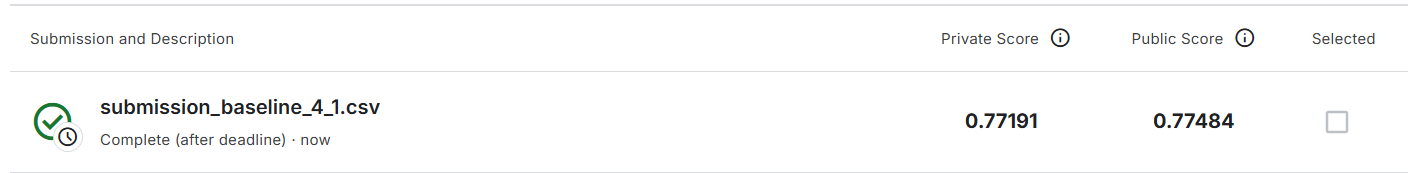

Как видим, качество модели ухудшелось, поэтому гипотеза не подтвердилась. 